## Data Analysis of Grain Crops in Manitoba between 2016 and 2020
This session looks in-depth at crop yield for grain crop varieties in Manitoba from different risk areas as reported by the Manitoba Agricultural Services Corporation (MASC). The data set shows yield information for various grain crops and their varieties, grouped by risk area and year. This data comes from reports by producers that insure with MASC only. The data set and description of entities can be found in the link below: https://data.winnipeg.ca/Manitoba-Agricultural-Services-Corporation/MASC-Crop-Yield-And-Acreage-By-Variety/5ctu-8526/data_preview.

In [1]:
# Import libraries and Load Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
url = "https://data.winnipeg.ca/resource/5ctu-8526.csv?$limit=5000000"
data = pd.read_csv(url)
data.head()

,cropyear,riskarea,crop_desc,variety_desc,acres,yieldamount,yield_unit,numberoffarms
0,2016,1,WHEAT RED SPRING,CDC GO (BW781),6528.0,41.76,BUS,13
1,2016,1,WHEAT RED SPRING,5602HR (BW297),656.0,31.97,BUS,3
2,2016,1,WHEAT RED SPRING,GLENN,6859.0,39.74,BUS,22
3,2016,1,WHEAT RED SPRING,MUCHMORE (BW875),923.0,33.56,BUS,5
4,2016,1,WHEAT RED SPRING,CARBERRY (BW874),27443.0,39.05,BUS,56


In [4]:
# View descriptive stat of the dataset and observe the columns with missing data
data.describe(include = 'all')

,cropyear,riskarea,crop_desc,variety_desc,acres,yieldamount,yield_unit,numberoffarms
count,22613.000000,22613.000000,22613,22613,22613.000000,22613.000000,22381,22613.000000
unique,NaN,NaN,49,734,NaN,NaN,4,NaN
top,NaN,NaN,ARGENTINE CANOLA,NO VAR,NaN,NaN,BUS,NaN
freq,NaN,NaN,5542,850,NaN,NaN,18550,NaN
mean,2017.901384,357.440897,NaN,NaN,3742.644395,108.861886,NaN,14.107814
std,1.414371,333.365341,NaN,NaN,9940.006975,336.697937,NaN,26.035716
min,2016.000000,1.000000,NaN,NaN,500.000000,0.000000,NaN,3.000000
25%,2017.000000,11.000000,NaN,NaN,871.000000,32.130000,NaN,4.000000
50%,2018.000000,282.000000,NaN,NaN,1505.000000,43.350000,NaN,7.000000
75%,2019.000000,671.000000,NaN,NaN,3123.500000,66.040000,NaN,14.000000


We can see here that the column "yield_unit" has quite a number of missing values. However, dropping these rows will not cause a significant alteration to the data set since it shows that about 232 ros do not have units

In [5]:
# Check out the data types of columns in the data set
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22613 entries, 0 to 22612
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cropyear       22613 non-null  int64  
 1   riskarea       22613 non-null  int64  
 2   crop_desc      22613 non-null  object 
 3   variety_desc   22613 non-null  object 
 4   acres          22613 non-null  float64
 5   yieldamount    22613 non-null  float64
 6   yield_unit     22381 non-null  object 
 7   numberoffarms  22613 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 1.4+ MB


In [6]:
# Confirm the number of missing values in the yield_unit column
data['yield_unit'].isnull().sum()

np.int64(232)

##### Next, I want to know how much number of acres of farmland changed over the years between 2016 and 2020. Is there an increase or decrease in the acres of land that were cultivated over the years?

In [7]:
# Start by grouping the 'acres' column by the 'cropyear' column. I want to use the mean as standard.

data_grp = data.groupby('cropyear')['acres'].mean()
data_grp = pd.DataFrame(data_grp)

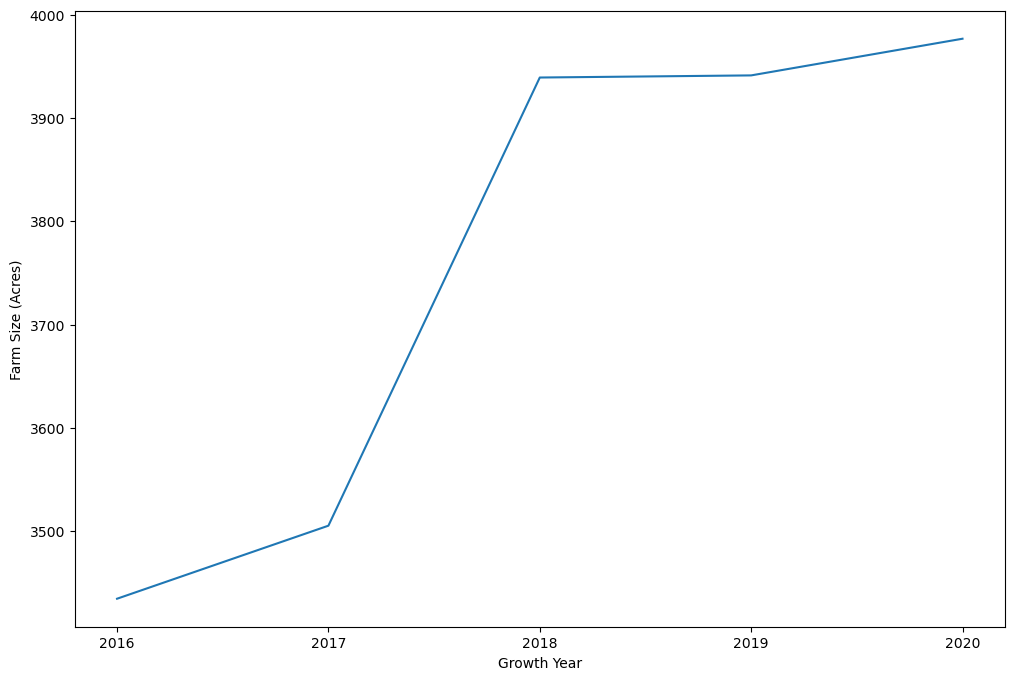

In [8]:
# Visualize this using a line plot.
# To prevent the 'cropyear' from having decimal ticks, there is need to import the MaxNLocator function

from matplotlib.ticker import MaxNLocator
plt.figure(figsize = (12, 8))
ax = sns.lineplot(data = data_grp, x = 'cropyear', y = 'acres')
ax.xaxis.set_major_locator(MaxNLocator(integer = True))
plt.xlabel('Growth Year')
plt.ylabel('Farm Size (Acres)')
plt.show()

Area of cultivated land increased over the years. Most importantly, there was a sharp increase in the area of cultivated land between 2017 and 2018. But was there a significant increase in crop yield between these years? We shall see.

In [9]:
# SImilarly, instead of acres, let's use 'numberoffarms'
# First, we group the average of 'numberoffarms' by the 'cropyear'

grp_data = data.groupby('cropyear')['numberoffarms'].mean()
grp_data = pd.DataFrame(grp_data)

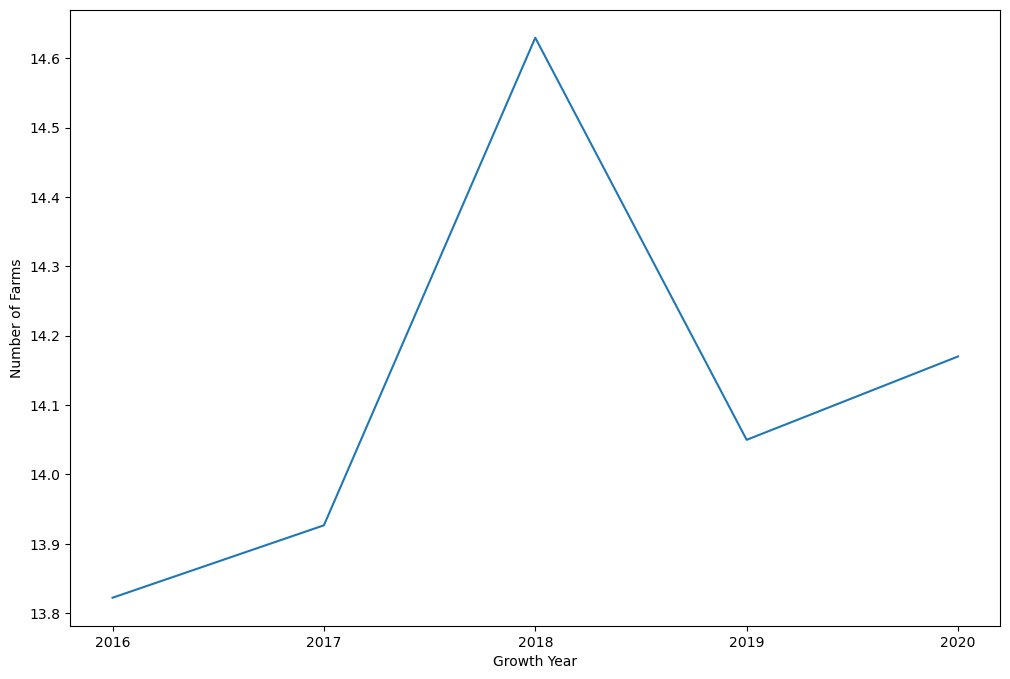

In [10]:
# Visualize using a line plot

plt.figure(figsize = (12, 8))
ax = sns.lineplot(data = grp_data, x = 'cropyear', y = 'numberoffarms')
ax.xaxis.set_major_locator(MaxNLocator(integer = True))
plt.xlabel('Growth Year')
plt.ylabel('Number of Farms')
plt.show()

Just like area of cultivated land, number of farms increased sharply between 2017 and 2018. However, unlike area of cultivated land, there was a drop in number of farms between 2018 and 2019. Not to speculate, but the increase in number of farms could be a result of land use conversion currently going on in Manitoba.

Since I was able to trace the missing data to the 'yield_unit' column, there is need for the missing values to be handled efficiently. To do this, I will drop the 232 missing rows, then standardize all units to Bushels before data analysis. The crops have different conversion factors and will be treated as such.

In [11]:
# Drop missing rows
data1 = data.dropna()
data1.shape

(22381, 8)

In [12]:
# Get the unique values in the 'yield_unit' column

data1['yield_unit'].unique()

array(['BUS', 'LBS', 'TON', 'CWT'], dtype=object)

In [13]:
# To use the yield amount and yield unit for data analytics, there is need to convert the units to a common unit and standardize the yield features
# Note that canola is a genetically improved rapeseed.

def classify_crop(crop):

    crop = str(crop)

    # Wheat family
    if 'WHEAT' in crop:
        return 'WHEAT'

    # Oats
    elif 'OATS' in crop:
        return 'OATS'

    # Barley
    elif 'BARLEY' in crop:
        return 'BARLEY'

    # Flax
    elif 'FLAX' in crop:
        return 'FLAX'

    # Rye
    elif 'RYE' in crop:
        return 'RYE'

    # Corn
    elif 'CORN' in crop:
        return 'CORN'

    # Soybeans
    elif 'SOYBEAN' in crop:
        return 'SOYBEAN'

    # Dry beans
    elif 'BEANS' in crop:
        return 'DRY_BEANS'

    # Peas
    elif 'PEAS' in crop:
        return 'PEAS'

    # Lentils
    elif 'LENTIL' in crop:
        return 'LENTILS'

    # Canola / Rapeseed
    elif 'CANOLA' in crop or 'RAPESEED' in crop:
        return 'CANOLA'

    # Sunflowers
    elif 'SUNFLOWER' in crop:
        return 'SUNFLOWER'

    # Mustard
    elif 'MUSTARD' in crop:
        return 'MUSTARD'

    # Buckwheat
    elif 'BUCKWHEAT' in crop:
        return 'BUCKWHEAT'

    # Canaryseed
    elif 'CANARYSEED' in crop:
        return 'CANARYSEED'

    # Millet
    elif 'MILLET' in crop:
        return 'MILLET'

    # Potatoes
    elif 'POTATO' in crop:
        return 'POTATOES'

    # Forage / hay crops
    elif any(x in crop for x in ['HAY', 'FORAGE', 'GREENFEED']):
        return 'FORAGE'

    else:
        return 'OTHER'

In [14]:
# Apply the crop classification
data1['crop_category'] = data1['crop_desc'].apply(classify_crop)

C:\Users\Nelson\AppData\Local\Temp\ipykernel_57572\486658803.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['crop_category'] = data1['crop_desc'].apply(classify_crop)


In [16]:
data['crop_category'] = data['crop_desc'].apply(classify_crop)

In [15]:
# Ascribe the conversion factors to the different crop categories

bushel_factors = {'WHEAT': 60,
                  'OATS': 32,
                  'BARLEY': 48,
                  'FLAX': 56,
                  'RYE': 56,
                  'CORN': 56,
                  'SOYBEAN': 60,
                  'DRY_BEANS': 60,
                  'PEAS': 60,
                  'LENTILS': 60,
                  'CANOLA': 50,
                  'SUNFLOWER': 30,
                  'MUSTARD': 50,
                  'BUCKWHEAT': 48,
                  'CANARYSEED': 50,
                  'MILLET': 50}

In [17]:
def convert_to_bushels(row):

    unit = row['yield_unit']
    value = row['yieldamount']
    category = row['crop_category']

    factor = bushel_factors.get(category)

    # Missing conversion factor
    if factor is None or pd.isna(value):
        return np.nan

    # Already BUS
    if unit == 'BUS':
        return value

    # Pounds
    elif unit == 'LBS':
        return value / factor

    # Hundredweight
    elif unit == 'CWT':
        return (value * 100) / factor

    # Tons (short ton = 2000 lbs)
    elif unit == 'TON':
        return (value * 2000) / factor

    else:
        return np.nan

In [18]:
# Apply the conversions to the data set
data['yield_BUS'] = data.apply(convert_to_bushels, axis=1)

In [19]:
data.head()

,cropyear,riskarea,crop_desc,variety_desc,acres,yieldamount,yield_unit,numberoffarms,crop_category,yield_BUS
0,2016,1,WHEAT RED SPRING,CDC GO (BW781),6528.0,41.76,BUS,13,WHEAT,41.76
1,2016,1,WHEAT RED SPRING,5602HR (BW297),656.0,31.97,BUS,3,WHEAT,31.97
2,2016,1,WHEAT RED SPRING,GLENN,6859.0,39.74,BUS,22,WHEAT,39.74
3,2016,1,WHEAT RED SPRING,MUCHMORE (BW875),923.0,33.56,BUS,5,WHEAT,33.56
4,2016,1,WHEAT RED SPRING,CARBERRY (BW874),27443.0,39.05,BUS,56,WHEAT,39.05


In [20]:
data[['crop_category', 'yield_BUS']].isnull().sum()

crop_category       0
yield_BUS        3053
dtype: int64

In [24]:
# Drop missing rows and select only necessary columns
new_data = data.dropna(subset = ['cropyear', 'riskarea', 'crop_category', 'variety_desc', 'acres', 'yield_BUS', 'numberoffarms'])
new_data.head()

,cropyear,riskarea,crop_desc,variety_desc,acres,yieldamount,yield_unit,numberoffarms,crop_category,yield_BUS
0,2016,1,WHEAT RED SPRING,CDC GO (BW781),6528.0,41.76,BUS,13,WHEAT,41.76
1,2016,1,WHEAT RED SPRING,5602HR (BW297),656.0,31.97,BUS,3,WHEAT,31.97
2,2016,1,WHEAT RED SPRING,GLENN,6859.0,39.74,BUS,22,WHEAT,39.74
3,2016,1,WHEAT RED SPRING,MUCHMORE (BW875),923.0,33.56,BUS,5,WHEAT,33.56
4,2016,1,WHEAT RED SPRING,CARBERRY (BW874),27443.0,39.05,BUS,56,WHEAT,39.05


In [27]:
# To determine whether to build a predictive model, perform correlation analysis on the important numeric variables

from scipy import stats
r, p_value = stats.pearsonr(new_data['yield_BUS'], new_data['numberoffarms'])
print('Pearson Correlation (r) is: ', r)
print('p-value is: ', p_value)

Pearson Correlation (r) is:  -0.006670359503258166
p-value is:  0.35089861276226547


The correlation analysis revealed that there was an extremely weak negative relationship between yield and number of farms. Furthermore, the relationship between the two variables was not significant.

In [28]:
# Correlation between yield and area of cultivated land

r, p_value = stats.pearsonr(new_data['yield_BUS'], new_data['acres'])
print('Pearson Correlation (r) is: ', r)
print('p-value is: ', p_value)

Pearson Correlation (r) is:  -0.028860665134454032
p-value is:  5.415038581735648e-05


The correlation analysis revealed that there was an extremely weak negative relationship between yield and area of cultivated land. However, their relationship was significant at p < 0.05.

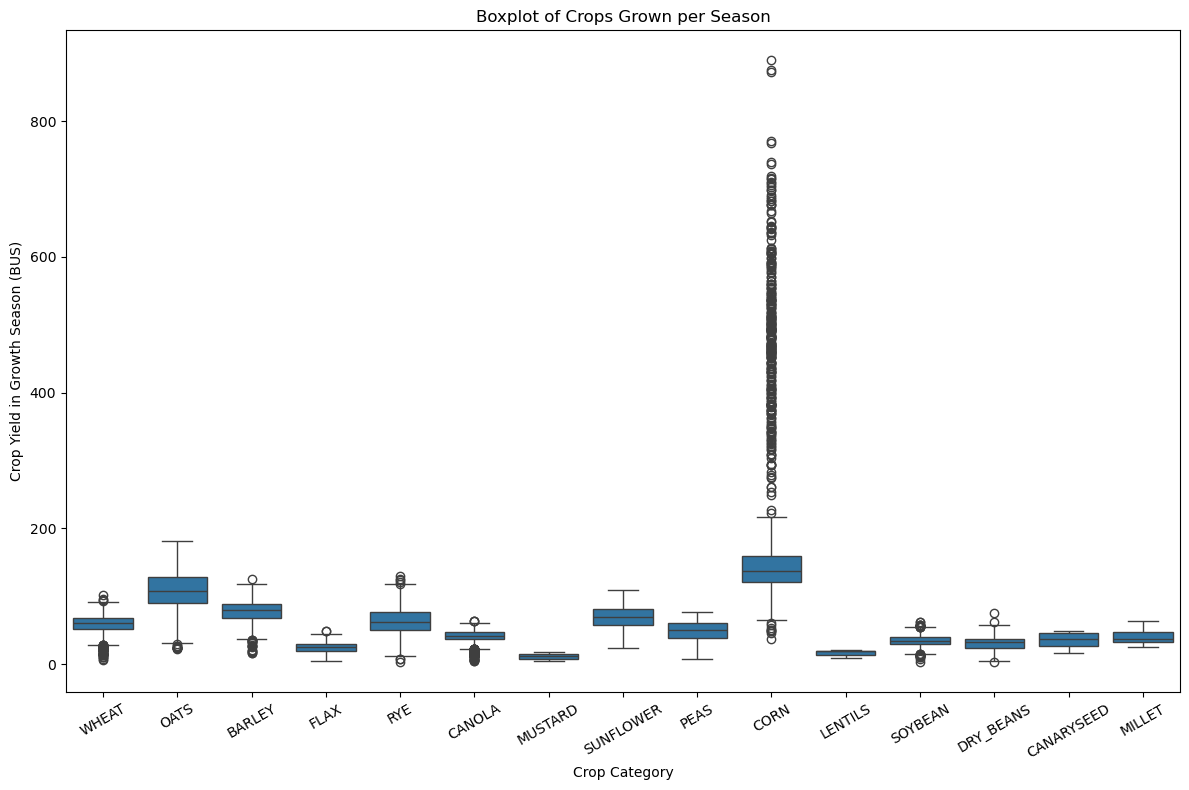

In [29]:
# Visualize the Cultivated Crops and their yields with Boxplots

plt.figure(figsize = (12, 8))
sns.boxplot(data = new_data, x = 'crop_category', y = 'yield_BUS')
plt.xlabel('Crop Category')
plt.ylabel('Crop Yield in Growth Season (BUS)')
plt.title('Boxplot of Crops Grown per Season')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

The boxplot showed that corn and oats produced the highest yield of all the cultivated crops. In addition, the corn crop had a lot of outliers, compared to other crops.

In [33]:
# Normalize the 'yield_BUS' column to reduce the number of outliers
new_data['yield'] = (new_data['yield_BUS'] - new_data['yield_BUS'].min())/(new_data['yield_BUS'].max() - new_data['yield_BUS'].min())

C:\Users\Nelson\AppData\Local\Temp\ipykernel_57572\594992939.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['yield'] = (new_data['yield_BUS'] - new_data['yield_BUS'].min())/(new_data['yield_BUS'].max() - new_data['yield_BUS'].min())


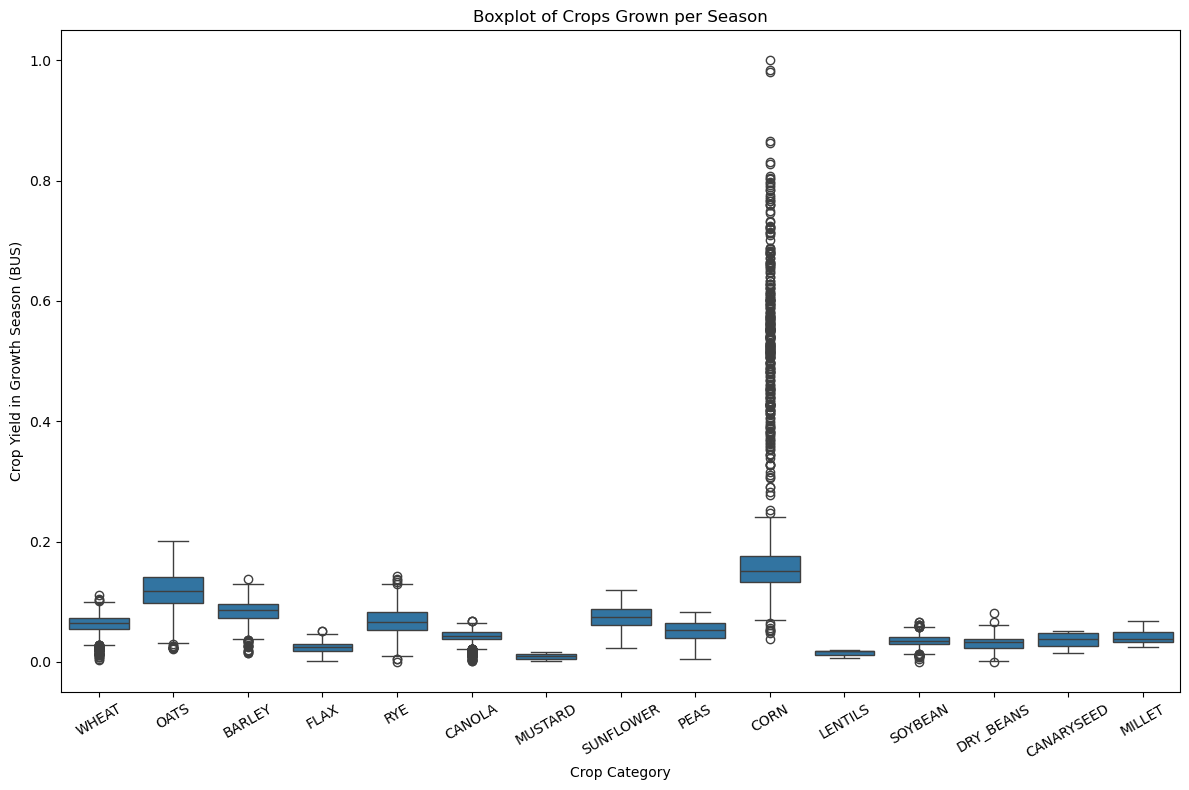

In [34]:
plt.figure(figsize = (12, 8))
sns.boxplot(data = new_data, x = 'crop_category', y = 'yield')
plt.xlabel('Crop Category')
plt.ylabel('Crop Yield in Growth Season (BUS)')
plt.title('Boxplot of Crops Grown per Season')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

Even the normalized 'yield' column produced the same output.

In [36]:
# Visualize the yield of crops grown in each year.
# First, slice out the yield per year

data_2016 = new_data[new_data['cropyear'] == 2016]
data_2017 = new_data[new_data['cropyear'] == 2017]
data_2018 = new_data[new_data['cropyear'] == 2018]
data_2019 = new_data[new_data['cropyear'] == 2019]
data_2020 = new_data[new_data['cropyear'] == 2020]

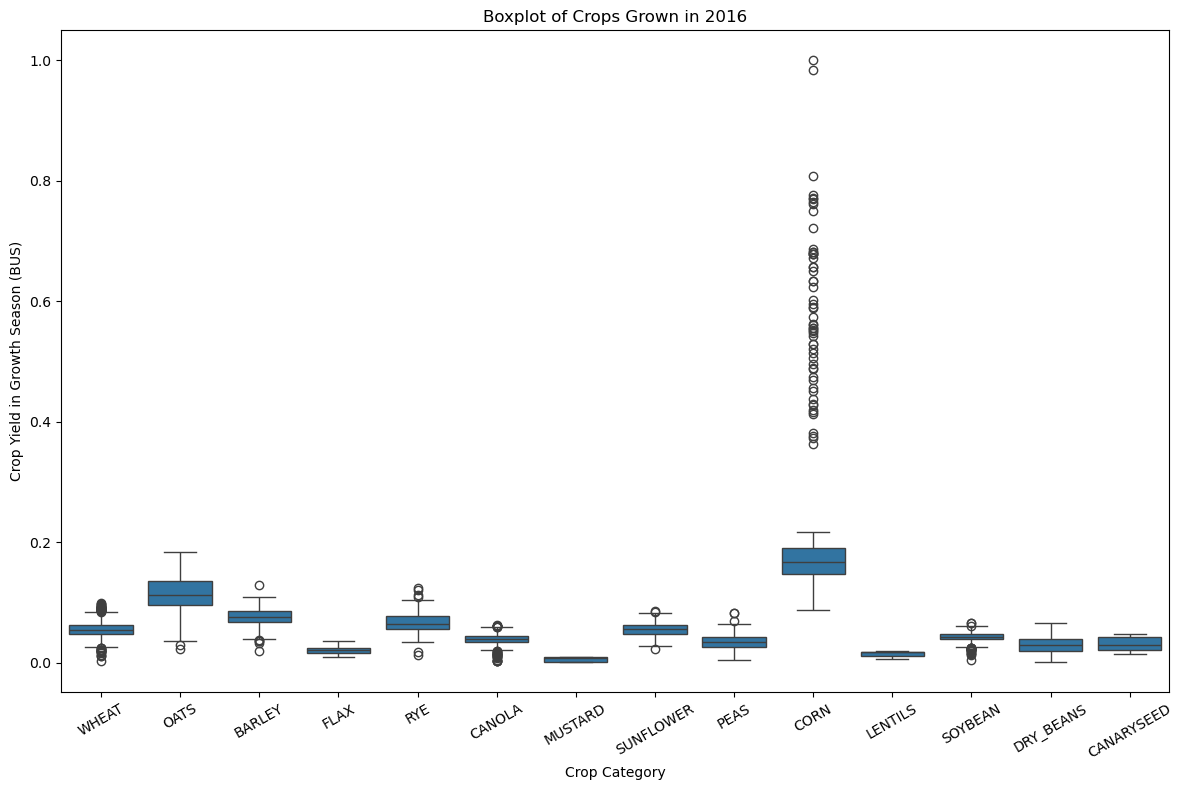

In [37]:
# Visualize the yield of crops grown in 2016

plt.figure(figsize = (12, 8))
sns.boxplot(data = data_2016, x = 'crop_category', y = 'yield')
plt.xlabel('Crop Category')
plt.ylabel('Crop Yield in Growth Season (BUS)')
plt.title('Boxplot of Crops Grown in 2016')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

The plot showed that 14 crop categories were cultivated in 2016, and of these crops, corn had the highest yield.

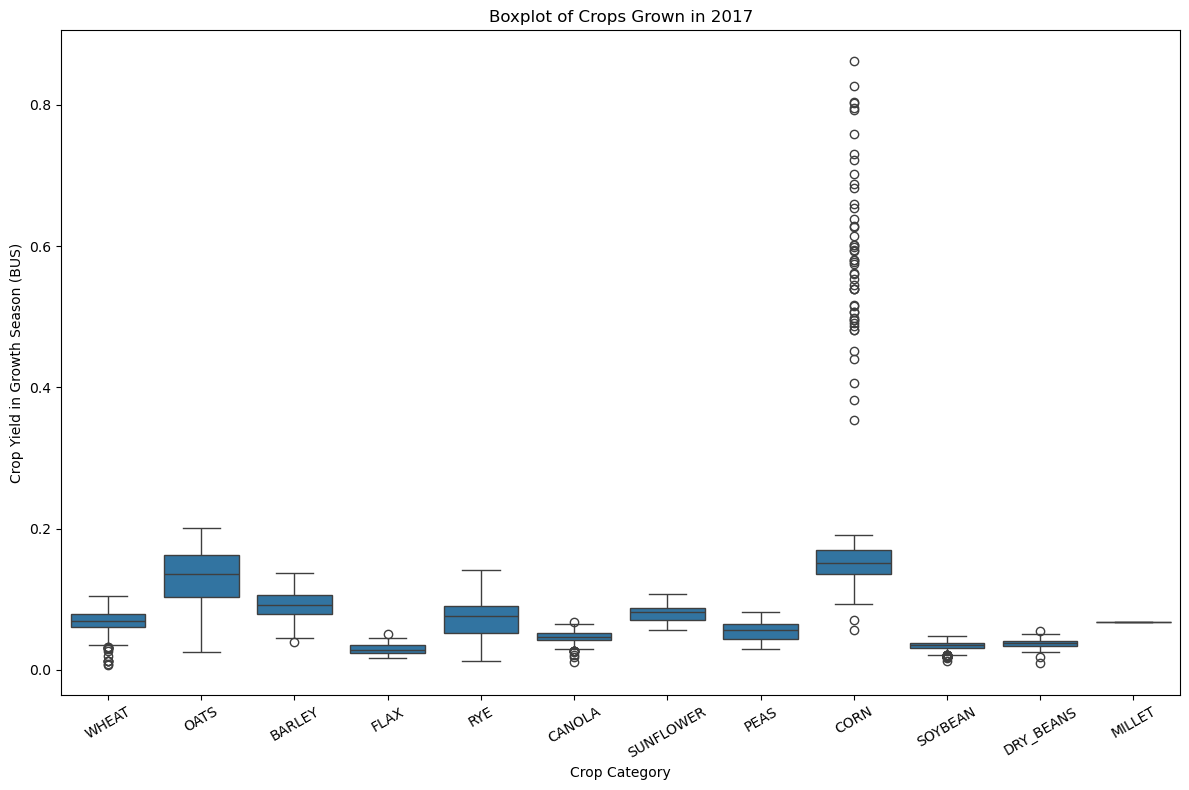

In [38]:
# Visualize the yield of crops grown in 2017

plt.figure(figsize = (12, 8))
sns.boxplot(data = data_2017, x = 'crop_category', y = 'yield')
plt.xlabel('Crop Category')
plt.ylabel('Crop Yield in Growth Season (BUS)')
plt.title('Boxplot of Crops Grown in 2017')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

The plot showed that 12 crop categories were cultivated in 2017, and of these crops, corn had the highest yield.

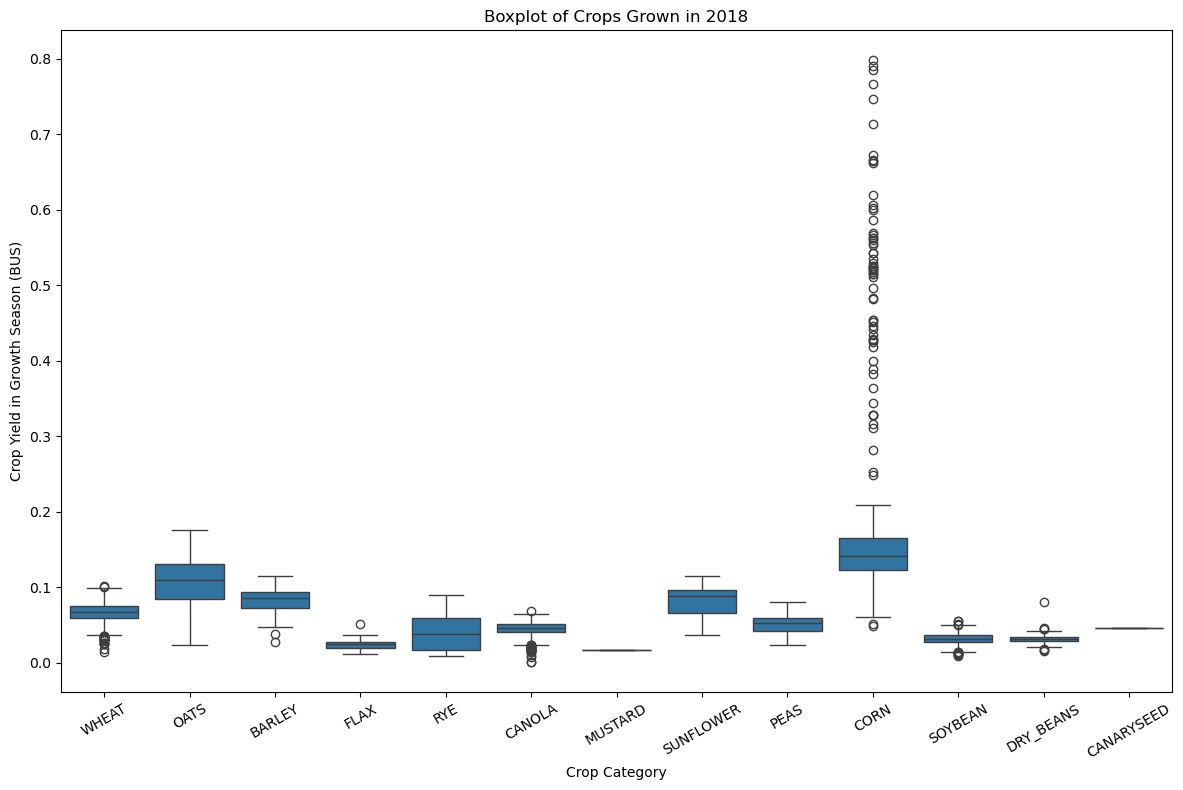

In [39]:
# Visualize the yield of crops grown in 2018

plt.figure(figsize = (12, 8))
sns.boxplot(data = data_2018, x = 'crop_category', y = 'yield')
plt.xlabel('Crop Category')
plt.ylabel('Crop Yield in Growth Season (BUS)')
plt.title('Boxplot of Crops Grown in 2018')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

The plot showed that 13 crop categories were cultivated in 2018, and of these crop categories, corn had the highest yield.

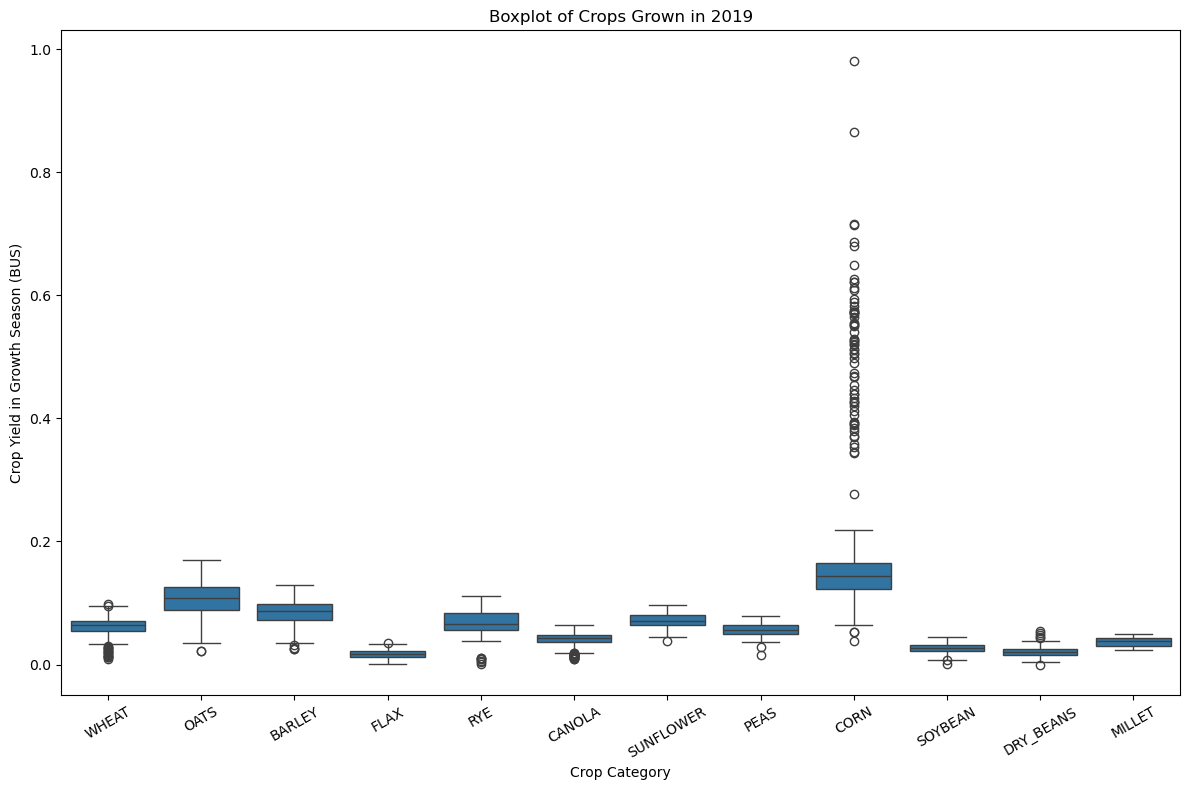

In [40]:
# Visualize the yield of crops grown in 2019

plt.figure(figsize = (12, 8))
sns.boxplot(data = data_2019, x = 'crop_category', y = 'yield')
plt.xlabel('Crop Category')
plt.ylabel('Crop Yield in Growth Season (BUS)')
plt.title('Boxplot of Crops Grown in 2019')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

The plot showed that 12 crop categories were cultivated in 2019, and of these crop categories, corn still had the highest yield.

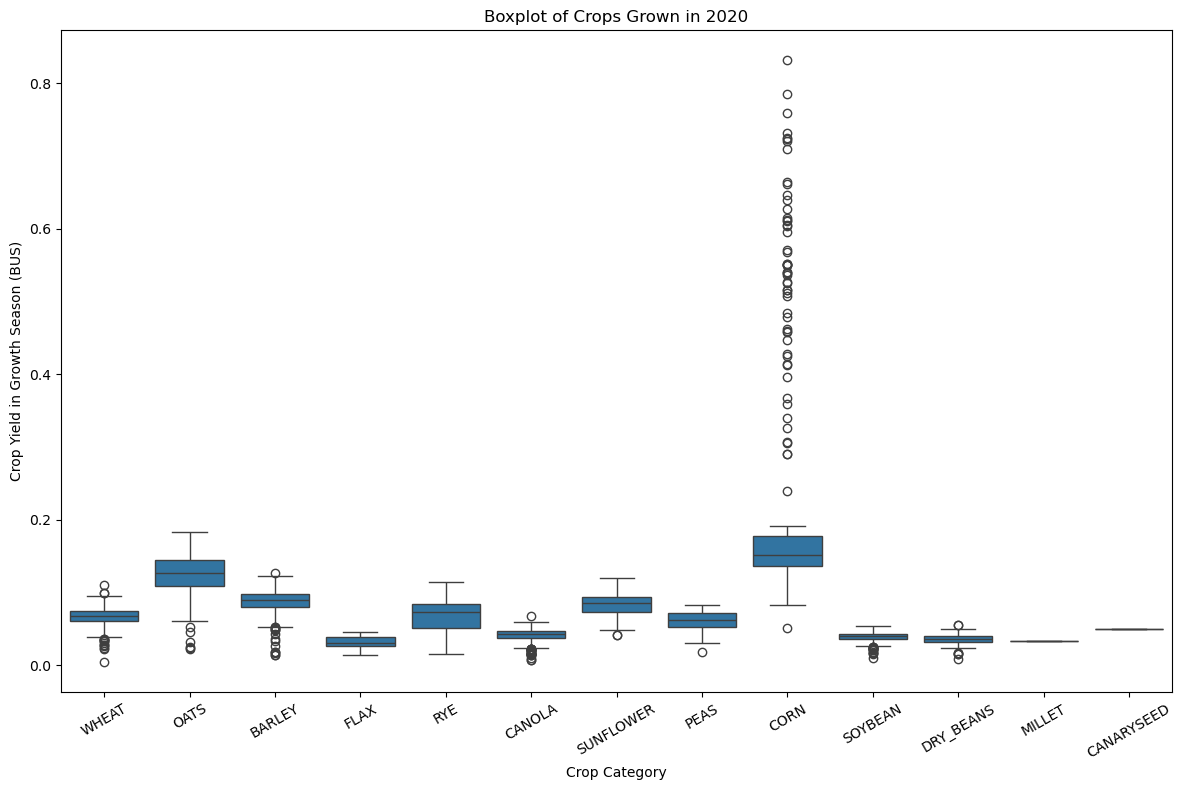

In [41]:
# Visualize the yield of crops grown in 2020

plt.figure(figsize = (12, 8))
sns.boxplot(data = data_2020, x = 'crop_category', y = 'yield')
plt.xlabel('Crop Category')
plt.ylabel('Crop Yield in Growth Season (BUS)')
plt.title('Boxplot of Crops Grown in 2020')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

The plot showed that 13 crop categories were cultivated in 2019, and of these crop categories, corn still had the highest yield.

In [50]:
# Top 15 Varieties with High Amount of Yield
top15_yield = new_data.sort_values('yield', ascending = False)
top_yield = top15_yield.head(15)
top_yield

,cropyear,riskarea,crop_desc,variety_desc,acres,yieldamount,yield_unit,numberoffarms,crop_category,yield_BUS,yield
3503,2016,611,CORN SILAGE,HL SR35 <DOW SEEDS>(RT),1462.0,24.90,TON,6,CORN,889.285714,1.000000
431,2016,4,CORN SILAGE,HL SR35 <DOW SEEDS>(RT),1747.0,24.50,TON,7,CORN,875.000000,0.983873
18250,2019,891,CORN SILAGE,AS1047RR EDF <PRIDE> (RT),616.0,24.44,TON,5,CORN,872.857143,0.981455
14704,2019,5,CORN SILAGE,AS1047RR EDF <PRIDE> (RT),1609.0,21.56,TON,21,CORN,770.000000,0.865344
5122,2017,2,CORN SILAGE,DKC35-54 <DEKALB> (RIB),507.0,21.50,TON,3,CORN,767.857143,0.862925
22366,2020,891,CORN SILAGE,AS1047RR EDF <PRIDE> (RT),557.0,20.72,TON,3,CORN,740.000000,0.831478
9786,2017,991,CORN SILAGE,P7958AM <PIONEER>,803.0,20.61,TON,3,CORN,736.071429,0.827043
4265,2016,812,CORN SILAGE,P7211HR <PIONEER>,525.0,20.15,TON,7,CORN,719.642857,0.808498
6119,2017,11,CORN SILAGE,P8210HR <PIONEER> (BT)(LT)(RT),1055.0,20.04,TON,3,CORN,715.714286,0.804063
6120,2017,11,CORN SILAGE,P7958AM <PIONEER>,852.0,20.02,TON,4,CORN,715.000000,0.803257


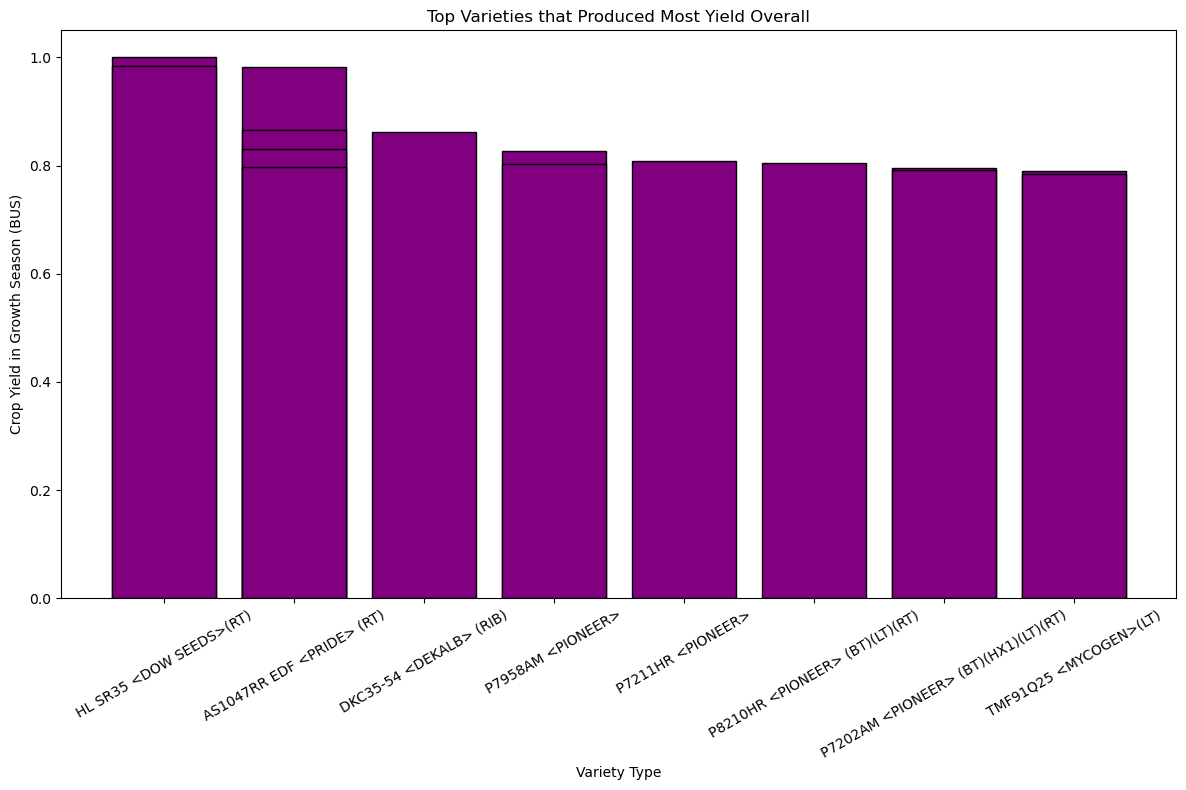

In [46]:
# Visualize the Highest Yielding Crop Varieties in the Data Set
plt.figure(figsize = (12, 8))
plt.bar(top_yield['variety_desc'], top_yield['yield'], color = 'purple', edgecolor = 'black')
plt.xlabel('Variety Type')
plt.ylabel('Crop Yield in Growth Season (BUS)')
plt.title('Top Varieties that Produced Most Yield Overall')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

The bar chart showed that varieties of corn silage had the highest yield. Of these, the variety, HL SR35 <DOW SEEDS>(RT) had the highest yield in the data set.

### Get Insight on Best Performing Crop Varieties of each Crop Category
Since the bar plot above showed that all the high yielding crop varieties belonged to the corn category, we might want to look at high yielding varieties of each crop category in the data set.

In [54]:
new_data['crop_category'].unique()

array(['WHEAT', 'OATS', 'BARLEY', 'FLAX', 'RYE', 'CANOLA', 'MUSTARD',
       'SUNFLOWER', 'PEAS', 'CORN', 'LENTILS', 'SOYBEAN', 'DRY_BEANS',
       'CANARYSEED', 'MILLET'], dtype=object)

In [60]:
# Top 15 Varieties with High Amount of Yield

def top_crop (crop):
    top_yield = new_data[new_data['crop_category'] == crop].sort_values('yield', ascending = False)
    top_variety = top_yield.head(15)
    
    plt.figure(figsize = (12, 8))
    plt.bar(top_variety['variety_desc'], top_variety['yield'], color = 'purple', edgecolor = 'black')
    plt.xlabel('Variety Type')
    plt.ylabel('Crop Yield in Growth Season (BUS)')
    plt.title(f'Top {crop} Varieties that Produced Most Yield Overall')
    plt.xticks(rotation = 30, ha = 'right')
    plt.tight_layout()
    plt.show()

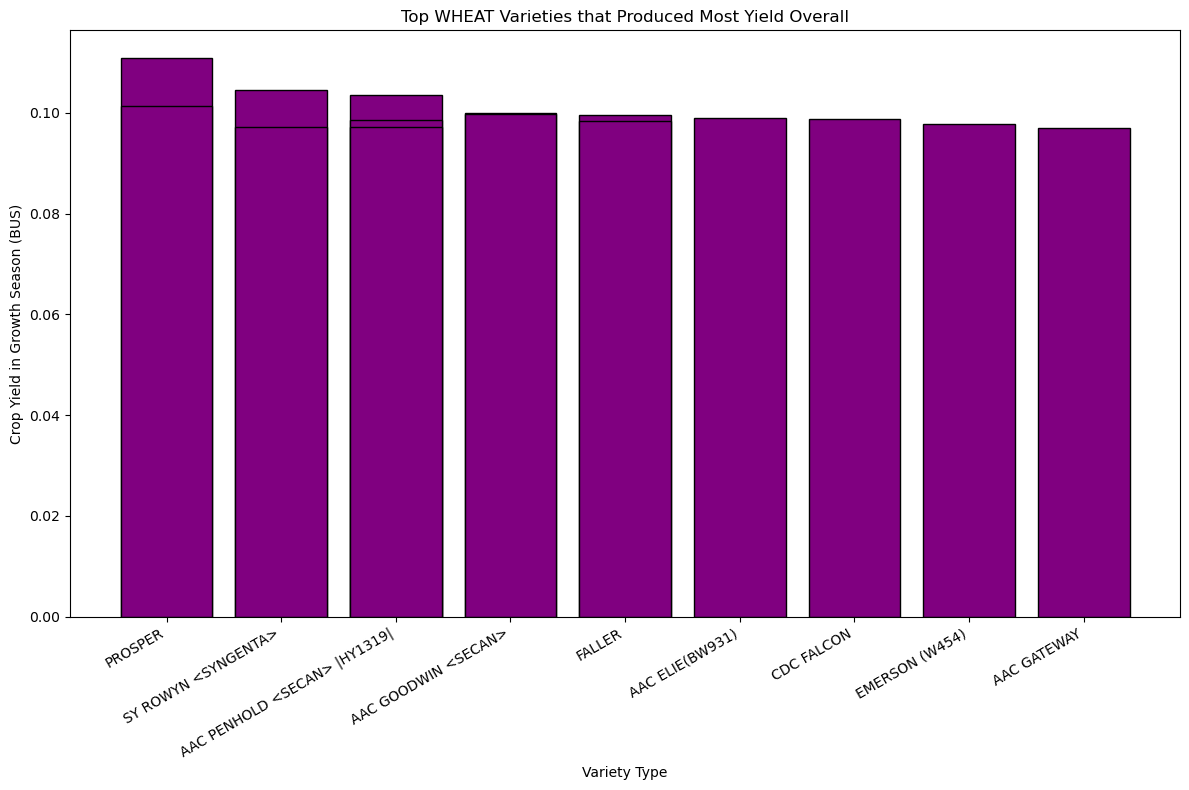

In [61]:
top_crop('WHEAT')

The bar plot revealed that the highest yielding wheat variety was the PROSPER variety

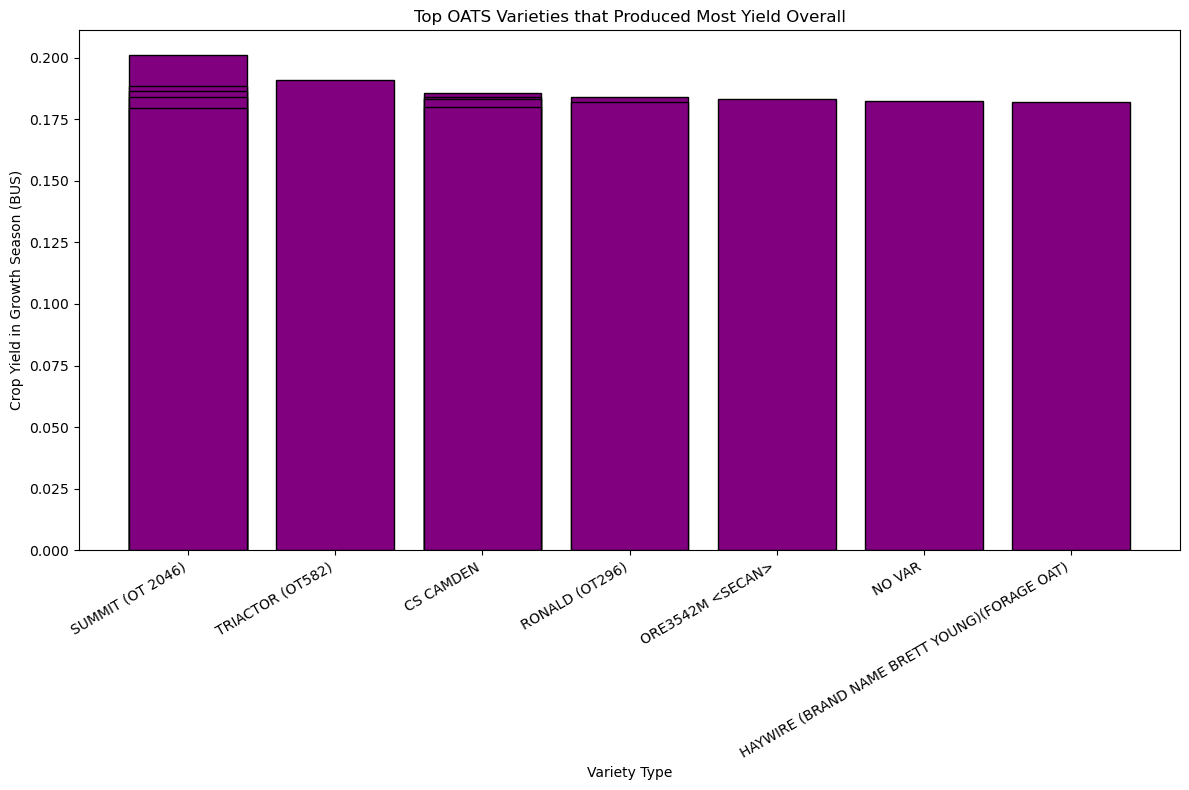

In [62]:
top_crop('OATS')

The bar plot revealed that the highest yielding oats variety was SUMMIT (OT 2046).

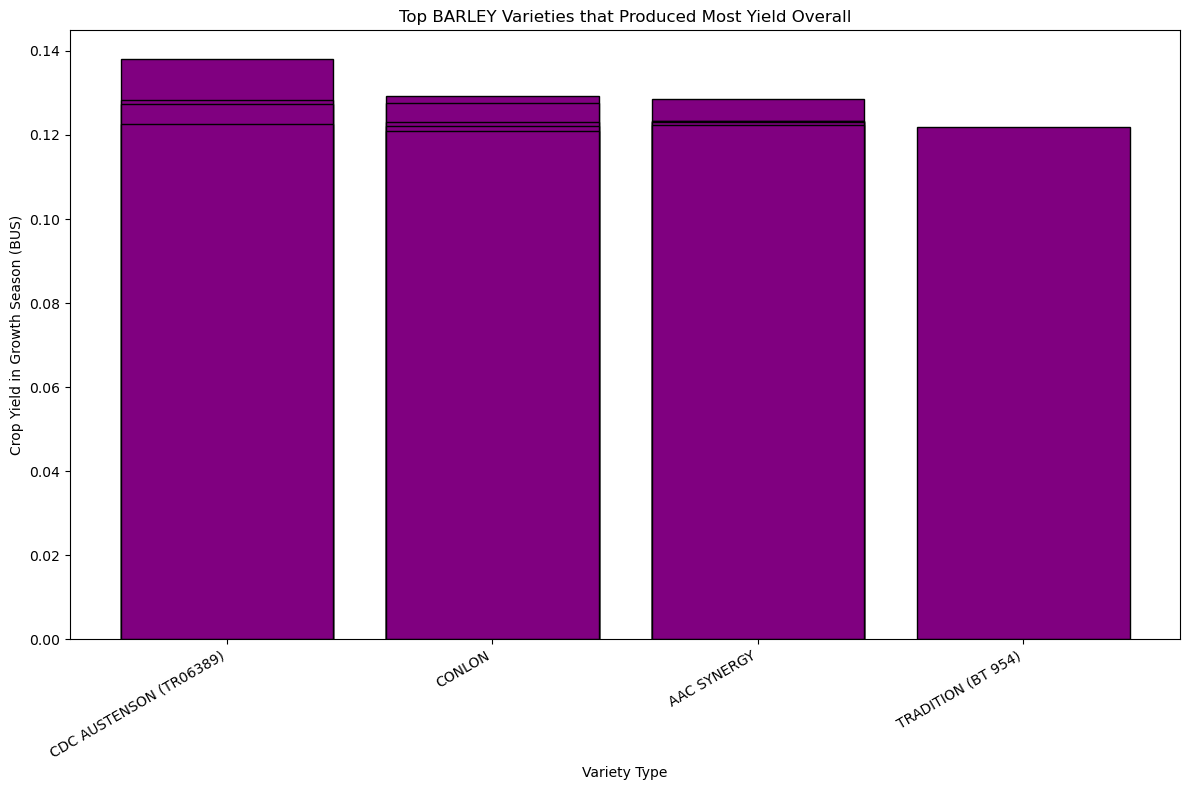

In [63]:
top_crop('BARLEY')

The bar plot revealed multiple occurrences of a few varieties as top yielding barley crop varieties. The highest yielding variety was the CDC AUSTENSON (TR06389) variety.

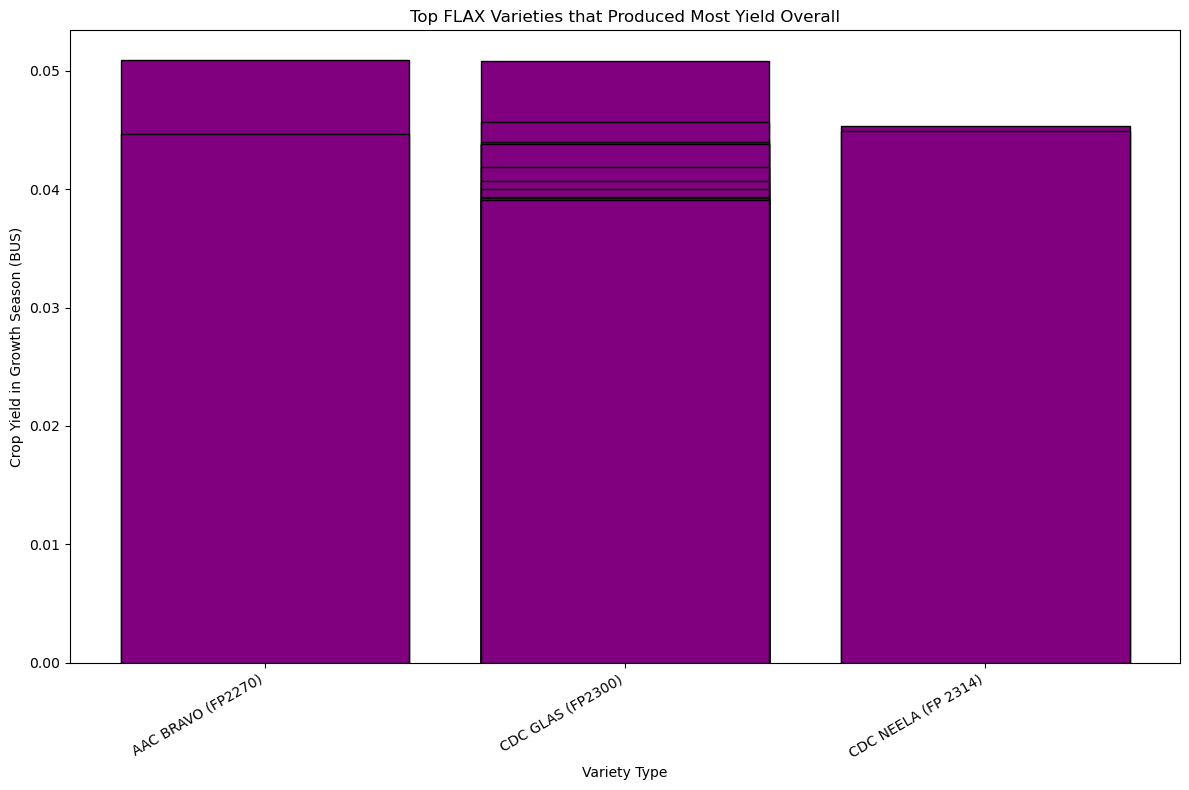

In [64]:
top_crop('FLAX')

The bar plot revealed multiple occurrences of a few varieties as top yielding flax crop varieties. The highest yielding variety was the AAC BRAVO (FP2270) variety.

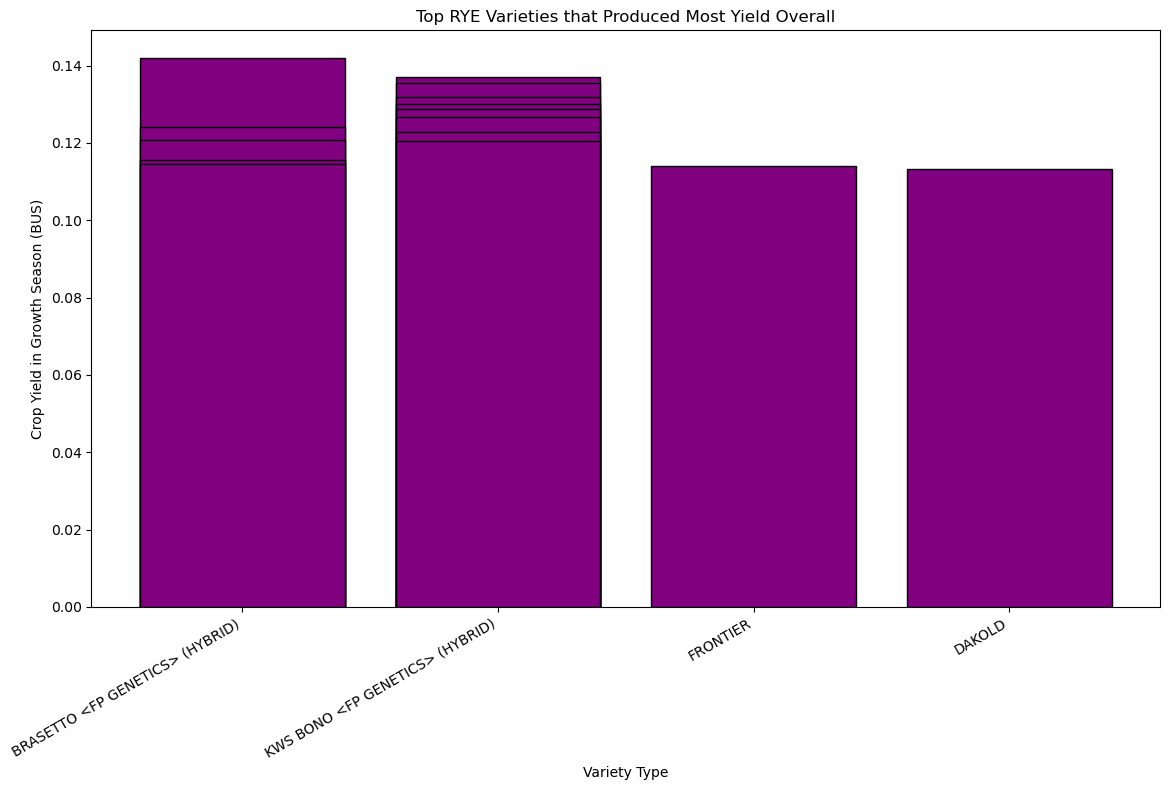

In [65]:
top_crop('RYE')

The bar plot revealed multiple occurrences of a few varieties as top yielding rye crop varieties. The highest yielding variety was the BRASETTO FP GENETICS (HYBRID) variety.

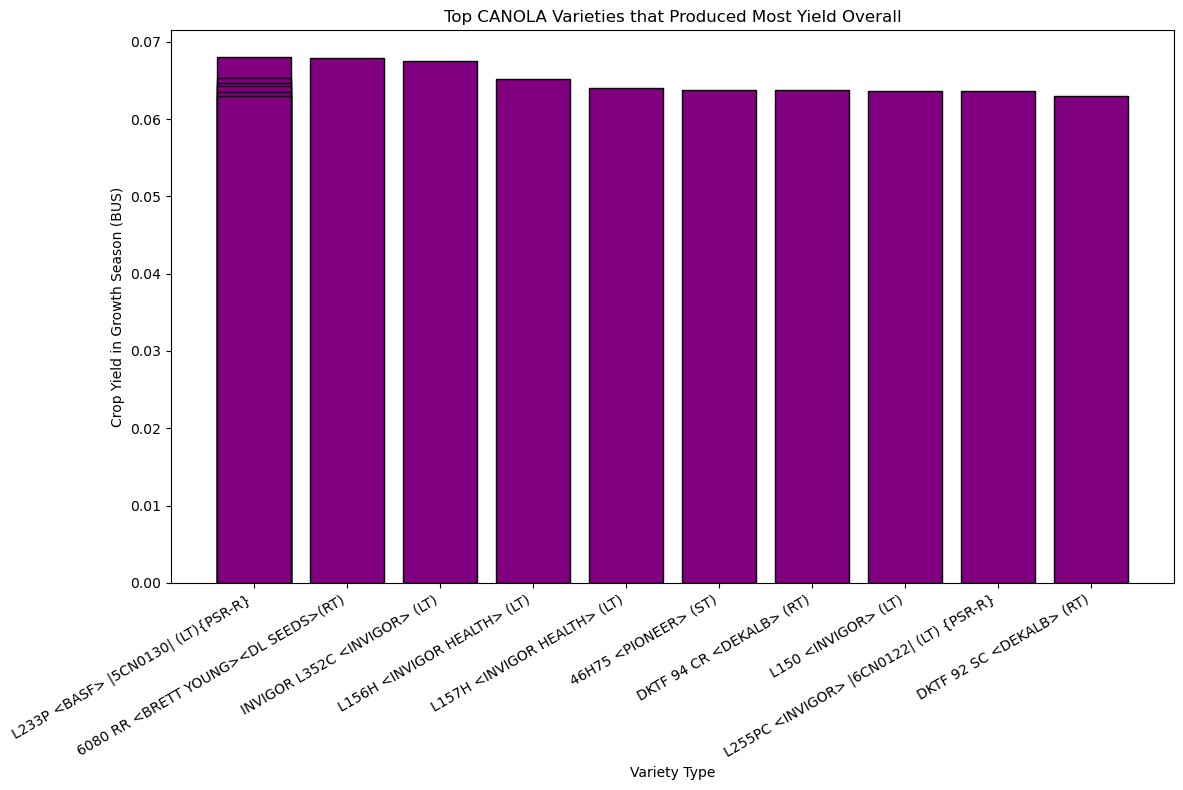

In [66]:
top_crop('CANOLA')

The bar plot revealed that the highest yielding variety of canola was the L233P BASF |5CN0130| (LT){PSR-R} variety.

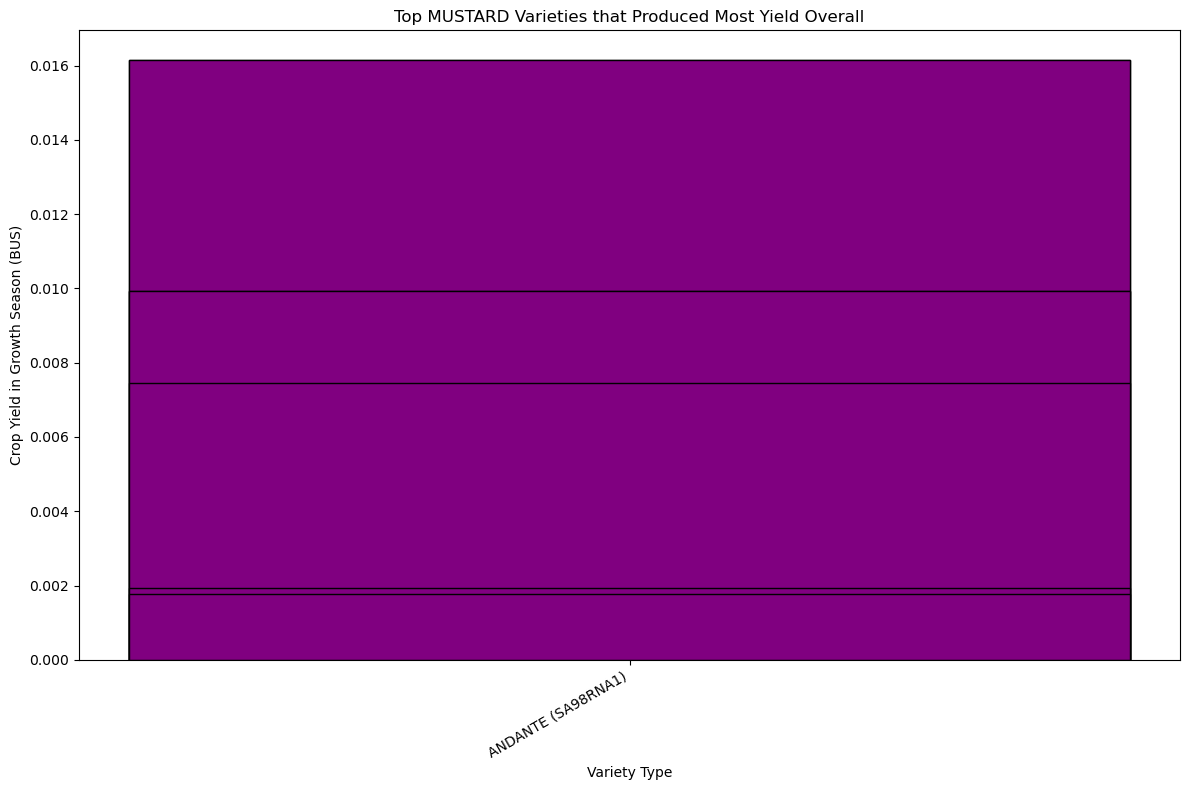

In [67]:
top_crop('MUSTARD')

The bar plot showed that mustard crop only had one variety (ANDANTE (SA98RNA1)

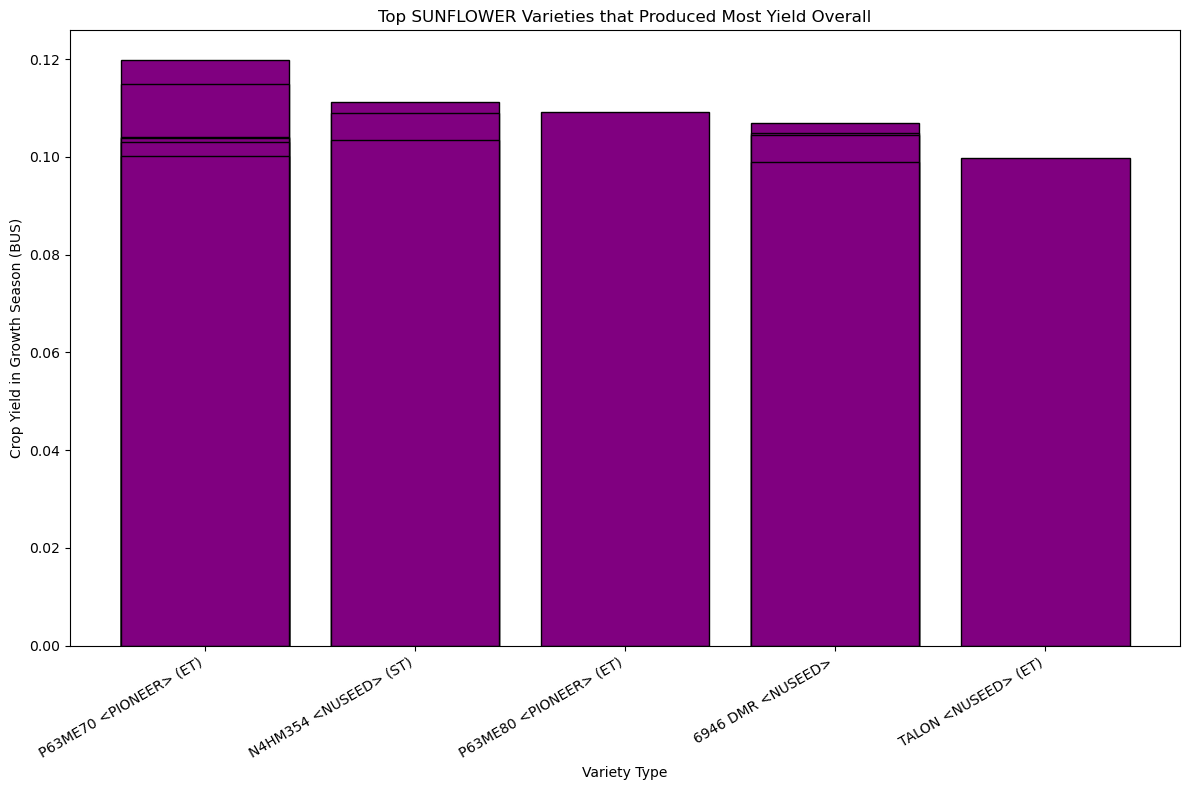

In [68]:
top_crop('SUNFLOWER')

The bar plot revealed that the highest yielding sunflower variety was the P63ME70 PIONEER (ET) variety.

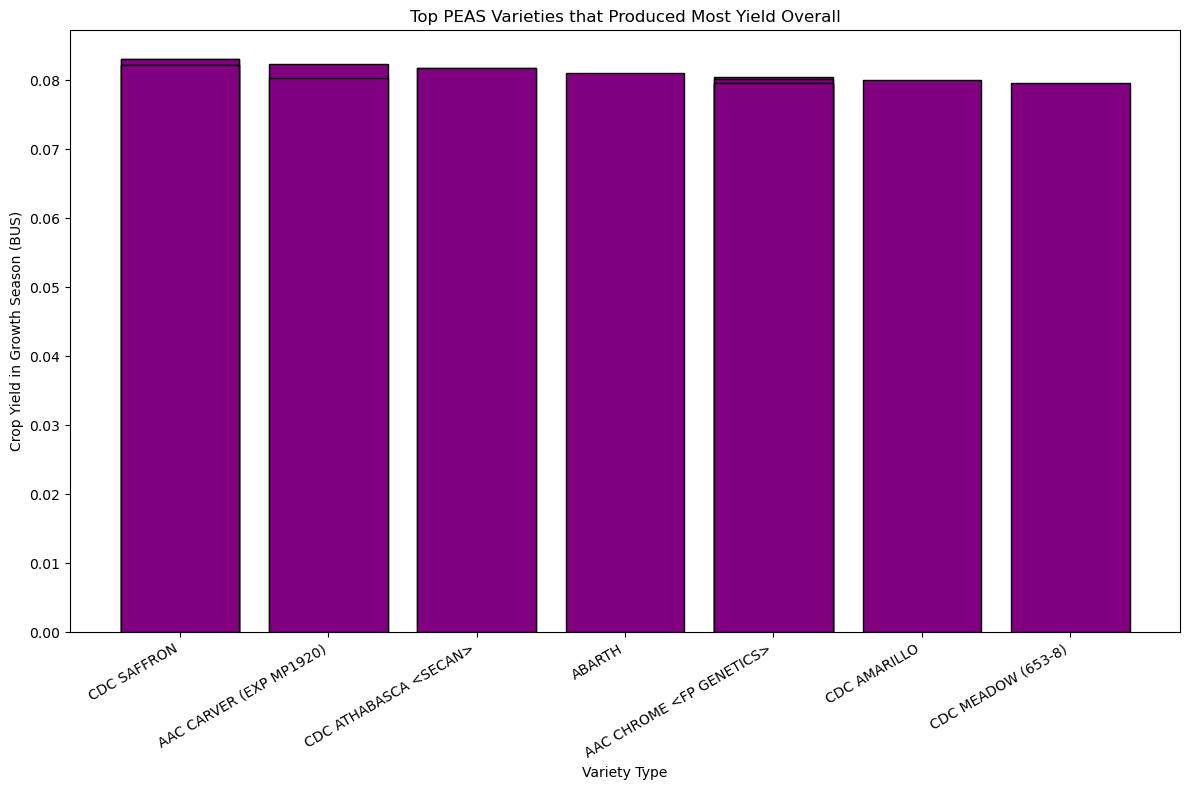

In [69]:
top_crop('PEAS')

The bar plot revealed that the highest yielding pea variety was the CDC SAFFRON variety.

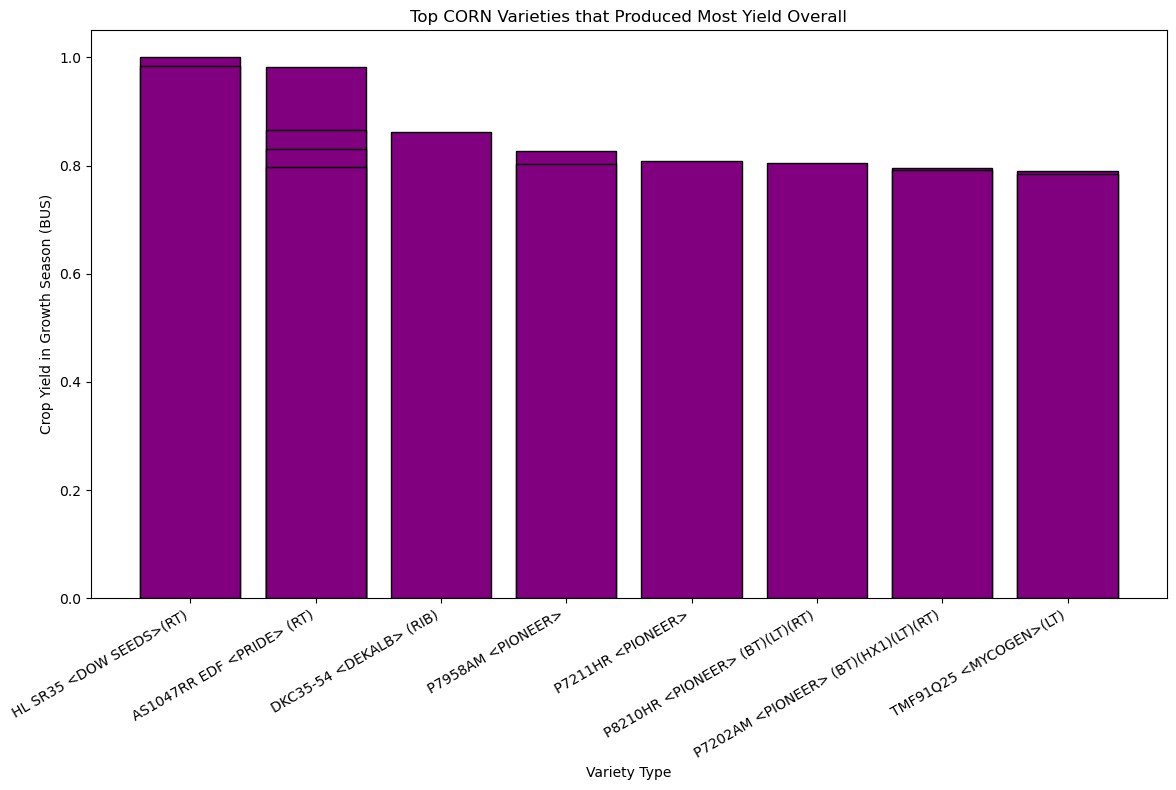

In [70]:
top_crop('CORN')

The bar plot revealed that the highest yielding corn variety was the HL SR35 DOW SEEDS (RT) variety.

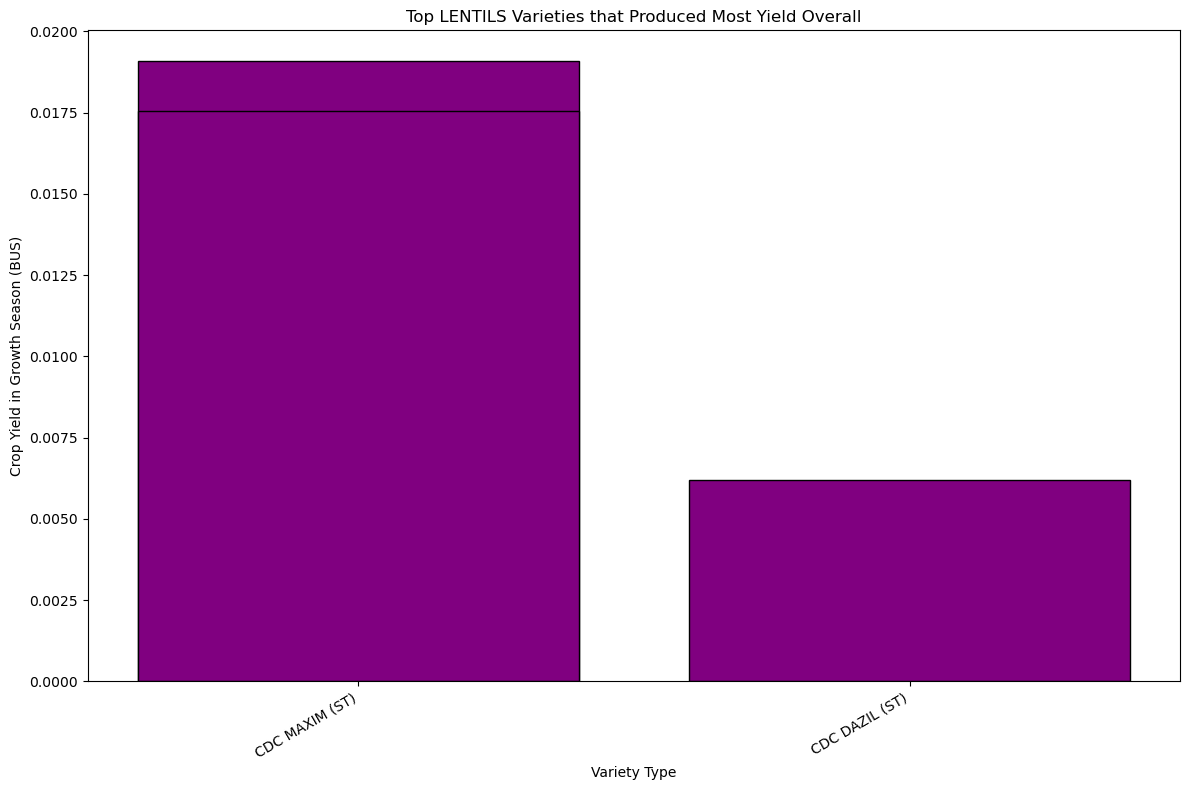

In [72]:
top_crop('LENTILS')

The bar plot revealed that there were just two varieties of lentils available in the data set. The CDC MAXIM (ST) had higher yield of the two varieties in the data set.

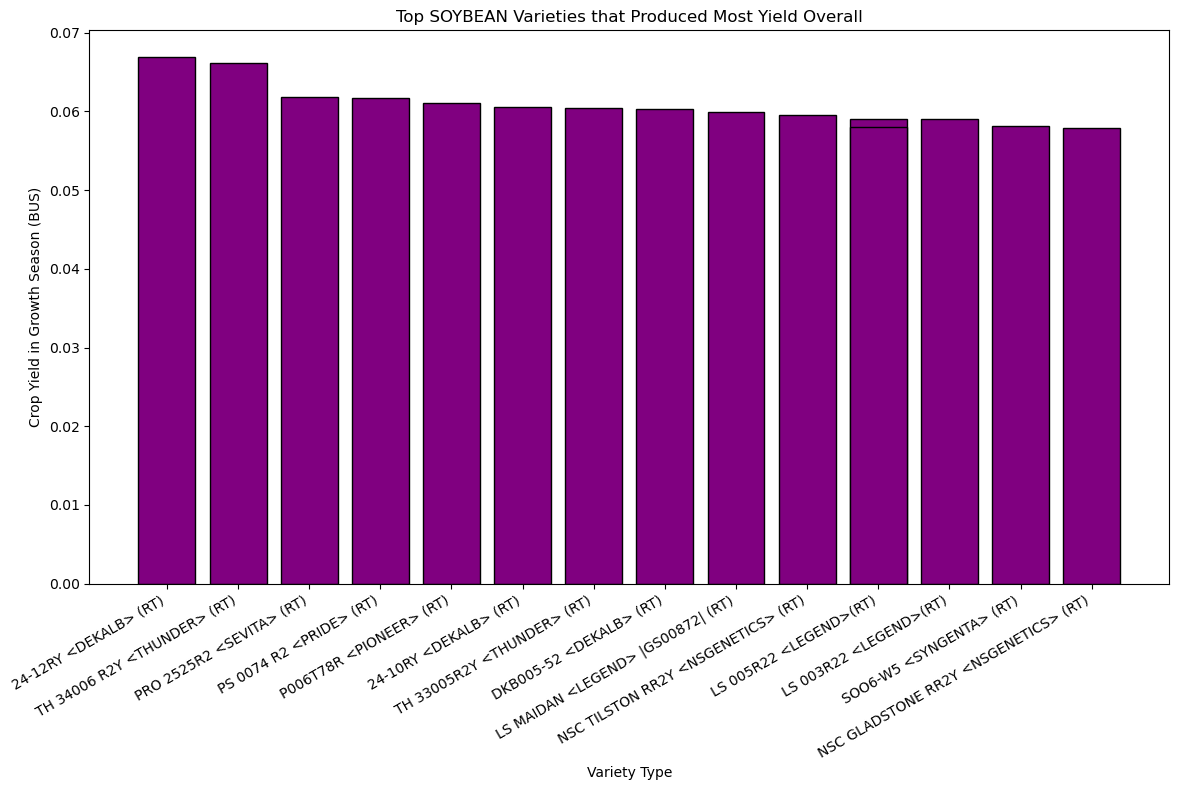

In [73]:
top_crop('SOYBEAN')

The bar plot revealed that the soybean variety with the highest yield in the data set was the 24-12RY DEKALB (RT) variety.

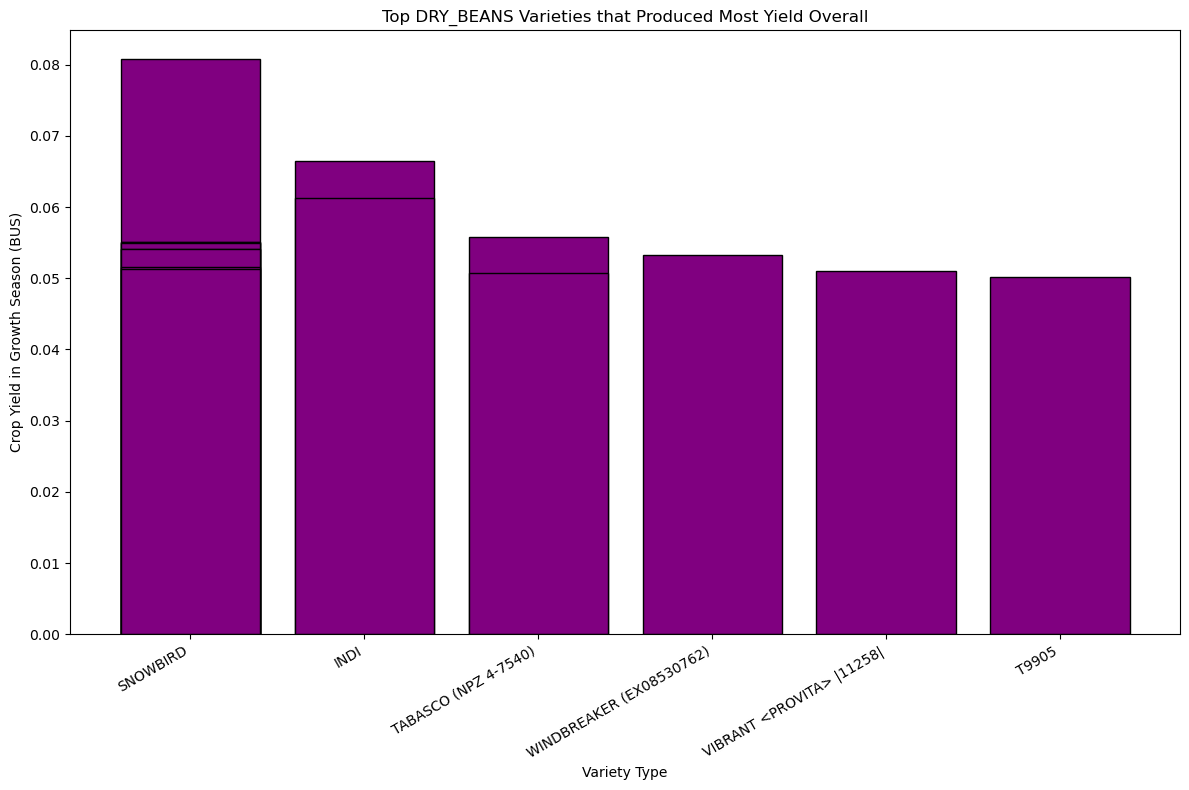

In [75]:
top_crop('DRY_BEANS')

The bar plot showed that the variety of dry bean with the highest yield was the SNOWBIRD variety.

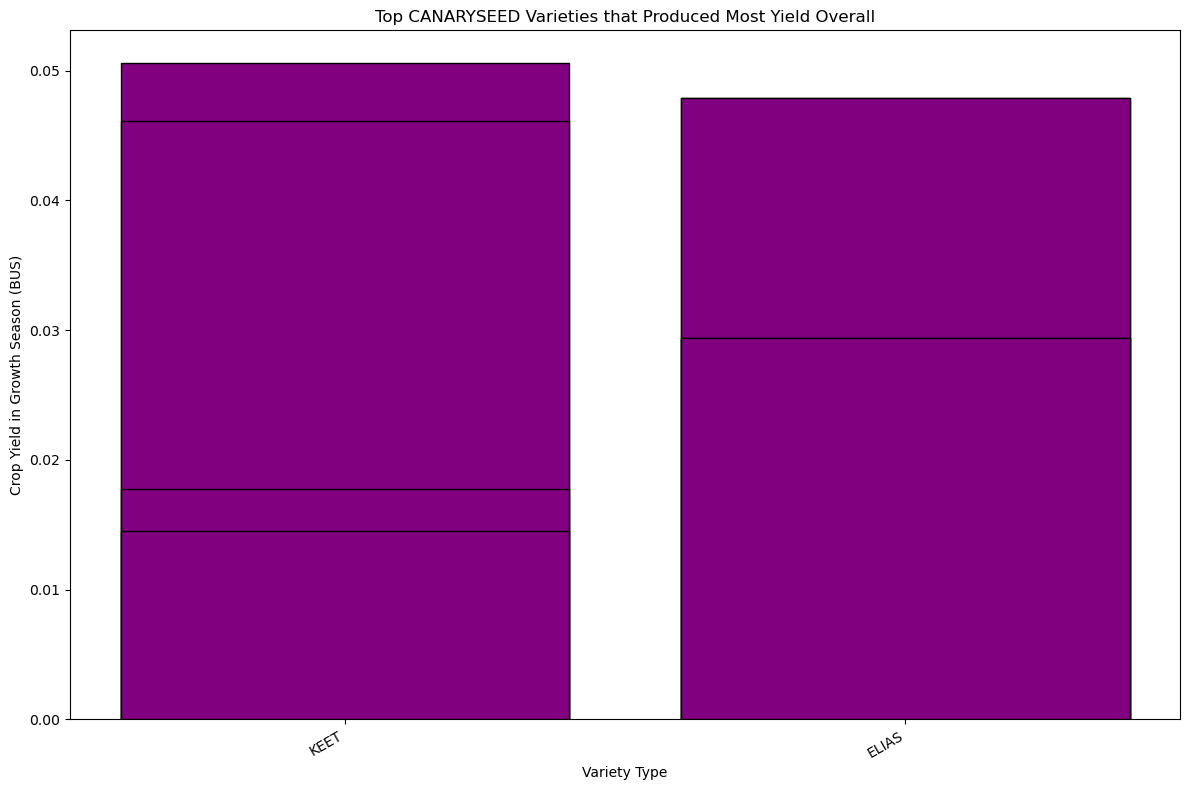

In [76]:
top_crop('CANARYSEED')

Canaryseed crop category only had two varieties. The variety with the higher yield in the data set was the KEET variety.

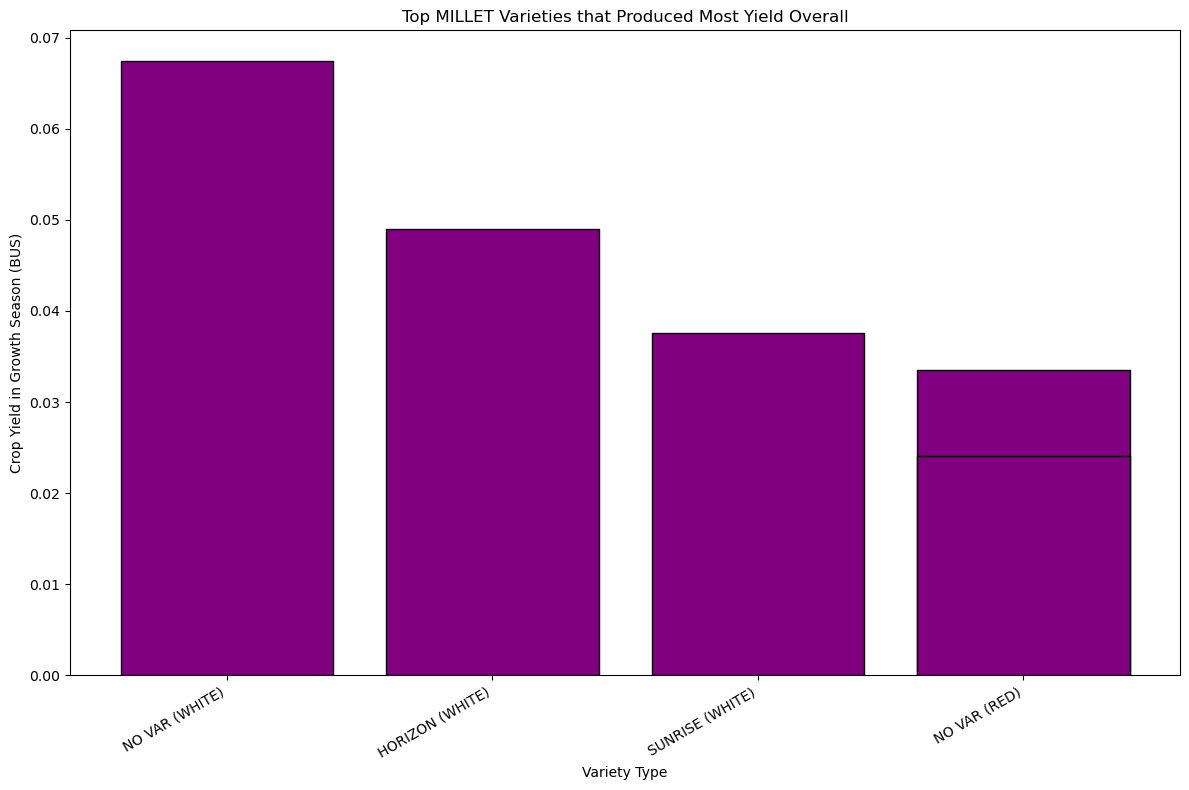

In [77]:
top_crop('MILLET')

The bar plot revealed that the millet variety with the highest yield in the data set was the NO VAR (WHITE) variety.

### Create Models to Test Yield
Since regression will be counterproductive and uninformative, two-way analysis of variance using cropyear and crop_desc as factors will be used to check if there is a significant difference in the means of yield across these factors. In addition, the model will show if there was a significant interaction between the factors.

In [51]:
# Convert the cropyear to string variable

new_data['cropyear'] = new_data['cropyear'].astype(str)

C:\Users\Nelson\AppData\Local\Temp\ipykernel_57572\773256071.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['cropyear'] = new_data['cropyear'].astype(str)


In [52]:
# Two-way Analysis of Variance

import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('yield_BUS ~ C(cropyear) * C(crop_category)', data = new_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                    sum_sq       df            F        PR(>F)
C(cropyear)                   1.101027e+05      4.0    14.437271  8.964824e-12
C(crop_category)              1.013432e+08     14.0  3796.764163  0.000000e+00
C(cropyear):C(crop_category)  6.464481e+05     56.0     6.054700  1.027788e-34
Residual                      3.717051e+07  19496.0          NaN           NaN


C:\Users\Nelson\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 14, but rank is 4
  warnings.warn('covariance of constraints does not have full '
C:\Users\Nelson\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 56, but rank is 46
  warnings.warn('covariance of constraints does not have full '


The model showed that yield differed significantly across both years and crop categories. Furthermore, there was a significant interaction between crop year and crop category.

In [53]:
# Perform a Generalized Linear Mixed Model (GLMM)
import statsmodels.api as sm
import statsmodels.formula.api as smf
glm_model = smf.glm(formula = 'yield_BUS ~ C(cropyear) * C(crop_category)', data = new_data, family = sm.families.Gaussian()).fit()
print(glm_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              yield_BUS   No. Observations:                19560
Model:                            GLM   Df Residuals:                    19496
Model Family:                Gaussian   Df Model:                           63
Link Function:               Identity   Scale:                          1906.6
Method:                          IRLS   Log-Likelihood:            -1.0159e+05
Date:                Wed, 13 May 2026   Deviance:                   3.7171e+07
Time:                        02:52:56   Pearson chi2:                 3.72e+07
No. Iterations:                   100   Pseudo R-squ. (CS):             0.6474
Covariance Type:            nonrobust                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

The Gaussian GLM model revealed a Pseudo_Rsquare value of 0.6474, which means that the factors accounted for about 64.74% of the variation in yield.
Compared to the reference year (2016), yield was significantly higher in 2017 and 2020. In addition, compared to the reference crop category (Barley), every other crop category had significantly higher yield except for Rye and Millet. Furthermore, corn category had the highest yield by far with a coefficient of 146.3611, while the mustard category produced the least yield with coefficient of -62.2771. This is not surprising since corn has higher weight than other grains.
Considering unique interactions between each year and crop against the reference categories of each of factors, only corn and soybean crop categories had significant interactions with all of the years. This means that both corn and soybean yields between 2017 to 2020 dropped significantly when compared to the reference year of 2016. However, other crop catehories such as oats (significant interactions with the years 2018 and 2019), Peas (significant interaction with 2020), and Rye (significant interaction with 2018) also existed in the model. The significant interactions between peas crop category and the crop year 2020 indicated that the yield of peas in this year increased significantly as evident in the positive coefficient.

### Gamma Generalized Linear Model
Let us perform a Gamma GLM model and compare the performance of the two models. The model with the lower aic value is the better performing model.

In [79]:
gamma_glm = smf.glm(formula = 'yield_BUS ~ C(cropyear) * C(crop_category)', data = new_data,
            family = sm.families.Gamma(link = sm.families.links.log())).fit()
print(gamma_glm.summary())

C:\Users\Nelson\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:              yield_BUS   No. Observations:                19560
Model:                            GLM   Df Residuals:                    19496
Model Family:                   Gamma   Df Model:                           63
Link Function:                    log   Scale:                        0.083577
Method:                          IRLS   Log-Likelihood:                -79223.
Date:                Thu, 14 May 2026   Deviance:                       1439.3
Time:                        00:19:50   Pearson chi2:                 1.63e+03
No. Iterations:                   100   Pseudo R-squ. (CS):             0.9811
Covariance Type:            nonrobust                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

The Gaussian GLM model revealed a Pseudo_Rsquare value of 0.9811, which means that the factors accounted for about 98.11% of the variation in yield.
Compared to the reference year (2016), yield significantly increased across the crop years. In addition, compared to the reference crop category (Barley), every other crop category had significant yield performance. However, only oats and corn had significantly higher yield than the reference crop category.
Although all the crop categories showed significant interaction with at least one crop year, corn and soybean crop categories showed significantly reduced yield performance across the growth years. Furthermore, peas and sunflower crop categories showed significantly higher yield performances across the crop years.

### Mixed Linear Model
Let us perform a Mixed Linear Model and compare the performance of the all models. The model with the least aic value is the better performing model.

In [81]:
from statsmodels.formula.api import mixedlm

mixed_model = mixedlm(formula = 'yield_BUS ~ C(cropyear) + C(crop_category)',
            data = new_data, groups = new_data['crop_desc']).fit(reml = False)

print(mixed_model.summary())

                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        yield_BUS  
No. Observations:        19560          Method:                    ML         
No. Groups:              36             Scale:                     436.5112   
Min. group size:         1              Log-Likelihood:            -87304.7910
Max. group size:         5542           Converged:                 Yes        
Mean group size:         543.3                                                
------------------------------------------------------------------------------
                                Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
------------------------------------------------------------------------------
Intercept                        77.895   43.620  1.786 0.074   -7.599 163.390
C(cropyear)[T.2017]               3.901    0.458  8.517 0.000    3.003   4.798
C(cropyear)[T.2018]              -1.647    0.470 -3.506 0.000   -2.568  -

The mixed linear model revealed that there was a high variability among the crops as seen in the group variance. Relative to the reference crop year of 2016, crop yield increased significantly in 2017, reduced significantly in 2018 and 2019, but increased significantly again in 2020. This fluctuation in yield with crop year could be as a result of changes in environmental variables.
Compared to the reference crop category, the yield of every other crop was significantly lower, however, the yield of the corn crop category was significantly higher. This goes to show that it is likely that increasing the area of cultivated lands between 2017 and 2018 did not significantly influence yield of crops.

### Model Selection
I have built three models but we can compare the performances of these models and choose the one that gives the best goodness-of-fit. A little caveat to this; I would pick the mixed linear model if I want to consider variability across group (crop names). However, since I am looking to predict the performance of my models for future, I will use the Akaike Information Criterion (AIC) method, where the model which gives the lowest aic will be selected.

In [84]:
print('The aic of the Gaussian GLM Model is:', glm_model.aic)
print('The aic of the Gamma GLM Model is:', gamma_glm.aic)
print('The aic of the Mixed Linear Model is:', mixed_model.aic)

The aic of the Gaussian GLM Model is: 203310.65679987913
The aic of the Gamma GLM Model is: 158574.50858837244
The aic of the Mixed Linear Model is: 174651.58199881975


From the output, it could be seen that the Gamma GLM model produced the least AIC.

### Conclusion

In conclusion, the analytical process revealed that there was an extremely weak relationship between yield and area of cultivated farmland (acres). Furthermore, the top yielding varieties of each crop category were visualized to enable farmers make informed decisions when choosing crop varieties to cultivate. Yield significantly dropped in some crop seasons, most likely because of some extreme environmental conditions. For instance, the extreme drought recorded in 2017 in Manitoba significantly reduced yield in that year. In contrast, the crop season of 2020 recorded significantly higher yield compared to other seasons, probably because despite average precipitation being low in that year, the amount of rainfall received during the critical growing season was sufficient enough and occurred at the appropriate time. Furthermore, much of the dryness reported in the 2020 crop year came during the harvest period which halped in preventing field rot. Particularly, even though Canola remains a critical Manitoba cash crop, the models showed that the corn category produced significantly higher yields of all crop categories across all growth years, owing likely to their high moisture content. This is not surprising since all top yielding varieties fell under the corn silage description. Therefore, owing to the ever changing weather pattern in Manitoba, the insights from these models will assist farmers in selecting varieties from each crop category that will critically suit any weather pattern. For instance, from the Gamma GLM model, Canola yield was significantly higher in 2020 when low precipitation prevented field rot and harvest season was perfect, whereas yield was not significant in other years.

### Data Analysis, Visualization and Statistical Modeling Performed by Nelson Uwalaka PhD (Plant Ecology), Certified IBM Data Analyst, Certified Digital Ag Professional